## Attention抽出

### Attentionとは

Attentionは、ニューラルネットワークにおいて、入力データの中で重要な部分に焦点を当てるメカニズム
特に自然言語処理や画像認識などの分野で広く使用されており、モデルが情報を効果的に処理できるようにするために役立つ

### Attentionの種類

- Self-Attention : 入力データ内の異なる部分が互いに注意を払うメカニズム。Transformerモデルで広く使用されている。
- Cross-Attention : 異なるデータセット間で注意を払うメカニズム。例えば、翻訳タスクでソース言語とターゲット言語の間で使用される。
- Multi-Head Attention : 複数の注意機構を並列に使用することで、異なる視点から情報を捉えることができる。

### Attentionの抽出方法

Attentionを抽出するには、以下の手順を実行する
1. モデルの準備 : Attentionメカニズムを含むニューラルネットワークモデルを用意する
2. フォワード : 入力データをモデルに通し、フォワードパスを実行する
3. Attentionマップ : モデルの中でAttentionが計算される層からAttentionマップを抽出する
4. 可視化 : Attentionマップを可視化して、どの部分が重要視されているかを確認する


In [38]:
DATA_PATH = "/Volumes/2T/data/raw"
DEVICE = "cpu"
SEED = 42
N_SPK = 10 # 話者数
N_UTT = 30 # 発話数
NUM_CLASSES = 10

In [33]:
import torchaudio

vctk = torchaudio.datasets.VCTK_092(DATA_PATH, download=True)

max_items = 10000 # 使用する音声数の上限(vctk全体は43872)

# 話者ごとの音声のインデックスリストを作成
spk2idx = {}
n = min(len(vctk), max_items)
for i in range(n):
    item = vctk[i]
    if len(item) >= 5:
        # (w, sr, utterance, spk, utt_id)
        spk = item[3]
    elif len(item) == 4:
        # (w, sr, spk, utterance)
        spk = item[2]
    spk2idx.setdefault(spk, []).append(i)

len(spk2idx) # 含まれる話者数

26

In [34]:
speakers = sorted(spk2idx.keys())
speakers[:10] # 最初の10人の話者を表示

['p225',
 'p226',
 'p227',
 'p228',
 'p229',
 'p230',
 'p231',
 'p232',
 'p233',
 'p234']

In [39]:
import random

# ランダムに話者と発話を選択(作為的バイアスを避けるため)
rnd = random.Random(SEED)
chosen = rnd.sample(speakers, k=N_SPK)
picks, valid = [], []
for spk in chosen:
    pool = spk2idx[spk]
    if len(pool) >= N_UTT:
        picks.extend(rnd.sample(pool, k=N_UTT))
        valid.append(spk)

print(f"{len(valid)}の話者を使用")
print(valid[:10])
print(f"{len(picks)}の発話を選択")
print(picks[:10])

10の話者を使用
['p247', 'p228', 'p225', 'p233', 'p232', 'p248', 'p229', 'p251', 'p244', 'p227']
300の発話を選択
[8058, 7972, 7772, 7771, 7803, 7867, 7875, 8014, 8064, 7769]


In [ ]:
# モデルの定義
import torch
import torch.nn as nn
import math

# 位置エンコーディング

class PositionalEncoding(nn.Module):
    #Transformerでよく使う位置エンコーディング（sin, cos 波で位置情報を付与）
    def __init__(self, d_model, max_len=4000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0)/d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe.unsqueeze(1))  # [T,1,D]
    def forward(self, x):  # x: [T,B,D]
        T, B, D = x.shape
        return x + self.pe[:T, :]

# Attentionを使った分類モデル
class AttentionClassifier(nn.Module):
    def __init__(self, input_dim, model_dim, num_heads, num_layers, num_classes, dropout=0.1):
        super().__init__()
        encoder_layer = nn.TransformerEncoderLayer(d_model=model_dim, nhead=num_heads, dropout=dropout)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.input_fc = nn.Linear(input_dim, model_dim)
        self.pos_encoder = PositionalEncoding(model_dim)
        self.classifier = nn.Linear(model_dim, num_classes)
        self.softmax = nn.Softmax(dim=-1)
    def forward(self, x):  # x: [T,B,D_in]
        x = self.input_fc(x)  # [T,B,D_model]
        x = self.pos_encoder(x)  # [T,B,D_model]
        x = self.transformer_encoder(x)  # [T,B,D_model]
        x = x.mean(dim=0)  # [B,D_model] - 平均プーリング
        x = self.classifier(x)  # [B,num_classes]
        x = self.softmax(x)  # [B,num_classes]
        return x

model = AttentionClassifier(input_dim=80, model_dim=256, num_heads=4, num_layers=4, num_classes=NUM_CLASSES).to(DEVICE)

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


In [ ]:
# モデルの学習
import torch.optim as optim
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
from torch.utils.data import DataLoader, Subset
batch_size = 16
target_length = 16000 * 10  # 10秒分の音声に揃える

# マッピング: 話者 -> ラベル（valid は既に定義済み）
spk2label = {spk: i for i, spk in enumerate(valid)}

# モデルへの入力は80次元のスペクトログラムとするため、音声データをスペクトログラムに変換する関数を定義
import torchaudio.transforms as T

def audio_to_spectrogram(audio):
    transform = T.MelSpectrogram(sample_rate=16000, n_mels=80)
    # 指定の長さに揃えるために、パディングまたはカットを行う
    if audio.size(1) < target_length:
        pad_size = target_length - audio.size(1)
        audio = torch.nn.functional.pad(audio, (0, pad_size))
    else:
        audio = audio[:, :target_length]

    return transform(audio)

# カスタム collate_fn を作って可変長波形による stack エラーを防ぐ
def collate_fn(batch):
    """
    batch: list of items from vctk (waveform, sample_rate, ..., speaker, ...)
    出力:
      inputs: [T, B, D] (torch.Tensor)
      targets: [B] (torch.long)
    """
    inputs = []
    targets = []
    for item in batch:
        waveform = item[0]  # waveform: [channels, time]
        # audio_to_spectrogram はセル下で定義済みなのでここで利用する
        spec = audio_to_spectrogram(waveform)  # [1, n_mels, T'] or similar
        # 先にセル7で行っている整形に合わせる: -> [T, D]
        spec = spec.squeeze(0).transpose(0, 1)  # [T, n_mels]
        inputs.append(spec)
        spk = item[3] if len(item) >= 5 else item[2]
        targets.append(spk2label[spk])
    # stack into [T, B, D]
    inputs = torch.stack(inputs, dim=1).to(DEVICE)  # [T, B, D]
    targets = torch.tensor(targets, dtype=torch.long, device=DEVICE)  # [B]
    return inputs, targets

train_dataset = Subset(vctk, picks)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True, collate_fn=collate_fn)
num_epochs = 5

# 学習 : タスクは話者分類
for epoch in range(num_epochs):
    model.train()
    for batch in train_loader:
        optimizer.zero_grad()
        inputs, targets = batch  # inputs: [T,B,D], targets: [B]
        outputs = model(inputs)  # [B, NUM_CLASSES]
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {loss.item()}")


Epoch 1/5, Loss: 2.1199254989624023
Epoch 2/5, Loss: 2.2995169162750244
Epoch 3/5, Loss: 2.2240118980407715
Epoch 4/5, Loss: 2.1727004051208496
Epoch 5/5, Loss: 2.18821382522583


In [62]:
# 正解率の計算
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for batch in train_loader:
        inputs, targets = batch
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        total += targets.size(0)
        correct += (predicted == targets).sum().item()
accuracy = 100 * correct / total
print(f"Training Accuracy: {accuracy:.2f}%")

Training Accuracy: 11.11%


In [ ]:
# 動作確認のため、ランダムに選んだ発話をモデルに通してみる
sample_idx = picks[0]
waveform, sample_rate, *rest = vctk[sample_idx]
spec = audio_to_spectrogram(waveform).squeeze(0).transpose(0, 1).unsqueeze(1).to(DEVICE)  # [T,1,80]
with torch.no_grad():
    output = model(spec)  # [1,NUM_CLASSES]
print(output)  # 話者ごとの確率分布

tensor([[0.0868, 0.0967, 0.0908, 0.0955, 0.0788, 0.1437, 0.1002, 0.0815, 0.0991,
         0.1269]])


In [ ]:
# Attentionの抽出方法
def extract_attention_weights(model, x):
    # TransformerEncoderLayerからAttentionの重みを抽出する関数
    attention_weights = []

    def get_attention(module, input, output):
        attn_output, attn_weights = module.self_attn(input[0], input[0], input[0], need_weights=True)
        attention_weights.append(attn_weights.detach().cpu())

    hooks = []
    for layer in model.transformer_encoder.layers:
        hook = layer.register_forward_hook(get_attention)
        hooks.append(hook)

    # モデルを通す
    with torch.no_grad():
        _ = model(x)

    # フックを外す
    for hook in hooks:
        hook.remove()

    return attention_weights  # 各層のAttention重みのリスト

attention_weights = extract_attention_weights(model, spec)  # [num_layers][B,num_heads,T,T]
attention_weights[0].shape  # 最初の層のAttention重みの形状を確認

torch.Size([1, 801, 801])

In [59]:
attention_weights[3]

tensor([[[0.0016, 0.0015, 0.0014,  ..., 0.0010, 0.0011, 0.0012],
         [0.0011, 0.0012, 0.0010,  ..., 0.0011, 0.0010, 0.0012],
         [0.0015, 0.0014, 0.0015,  ..., 0.0012, 0.0012, 0.0012],
         ...,
         [0.0014, 0.0015, 0.0016,  ..., 0.0012, 0.0012, 0.0010],
         [0.0014, 0.0014, 0.0015,  ..., 0.0007, 0.0013, 0.0013],
         [0.0014, 0.0014, 0.0015,  ..., 0.0014, 0.0008, 0.0014]]])

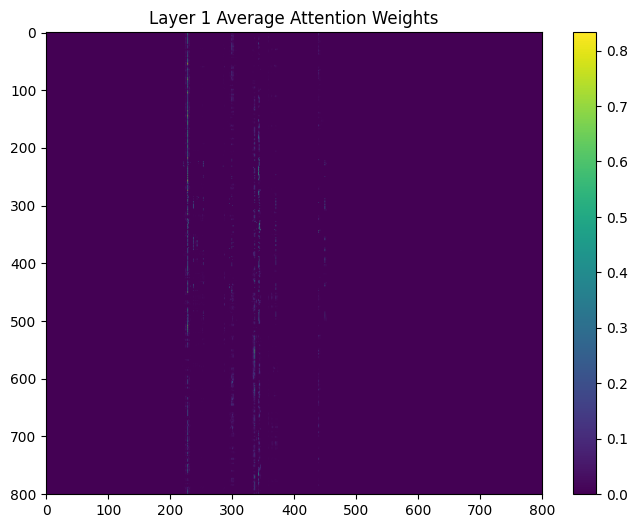

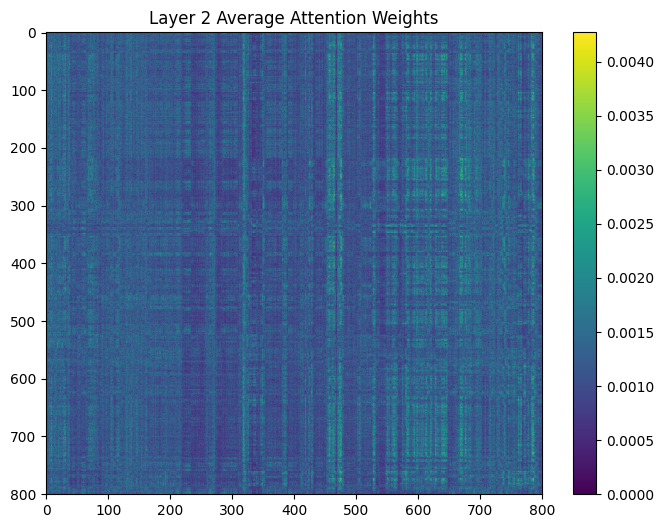

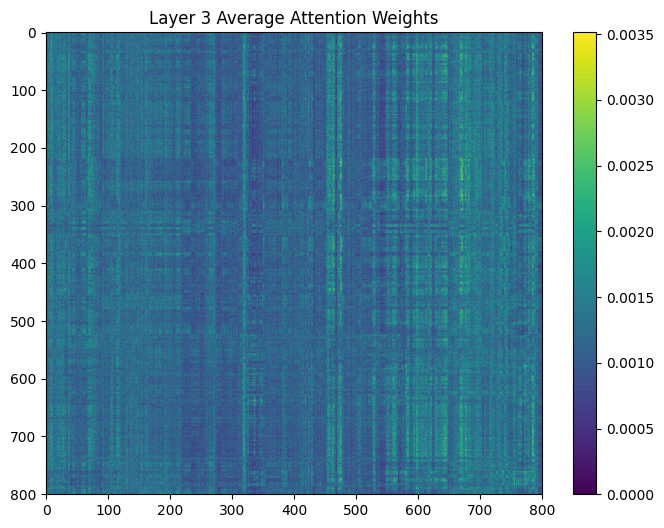

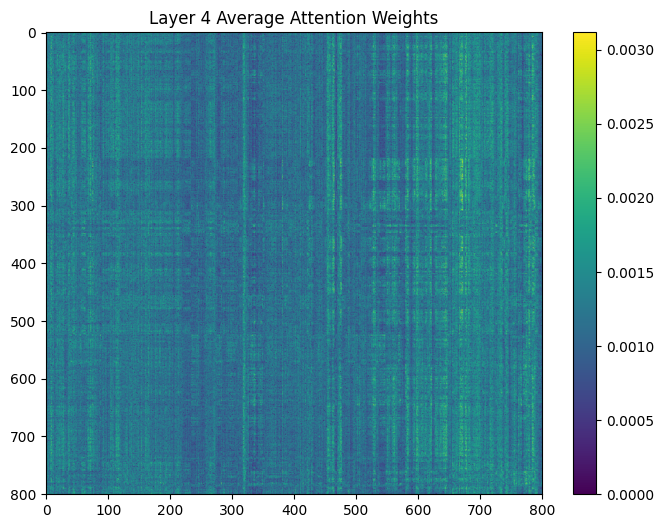

In [ ]:
# Attentionの可視化
# 横軸: 時間ステップ、縦軸: 各時間ステップのAttentionの大きさの平均
import matplotlib.pyplot as plt
# 各層のAttention重みを平均化してプロット
for layer_idx, attn in enumerate(attention_weights):
    plt.figure(figsize=(8, 6))
    plt.imshow(attn.squeeze(0), cmap='viridis', aspect='auto')
    plt.colorbar()
    plt.title(f'Layer {layer_idx+1} Average Attention Weights')
    plt.show()

# 縦軸は時間ステップ、横軸は各時間ステップのAttentionの大きさの平均
# attn.squeeze(0)　はバッチサイズ1を取り除く操作
# なぜattnは801*801の形状になるのか
# attnの形状は[B, num_heads, T, T]であり、B=1, num_heads=4, T=801の場合、attn.squeeze(0)は[num_heads, T, T]となる
# 縦軸は時間ステップ、横軸も時間ステップであり、各時間ステップが他のすべての時間ステップに対してどれだけ注意を払っているかを示している
# 具体的には、(i, j)の位置にある値は、時間ステップiが時間ステップjに対してどれだけ注意を払っているかを示す
# 他の時間ステップに注目することの意味は、モデルがある時間ステップの情報を他の時間ステップからどれだけ取り入れているかを示している
# つまり、ある音声フレームが他のフレームにどれだけ依存しているか、または関連しているかを理解するのに役立つ
# 例えば、ある音声フレームが他のフレームに高いAttentionを示している場合、そのフレームは他のフレームから多くの情報を引き出している可能性がある
# 逆に、低いAttentionを示している場合、そのフレームは他のフレームからあまり情報を引き出していない可能性がある
# 多くの情報を引き出しているフレームは、音声の特徴やパターンを理解する上で重要な役割を果たしている可能性がある
# したがって、Attentionマップを分析することで、モデルが音声データのどの部分に注目しているか、そしてどのように情報を統合しているかを理解する手がかりとなる